In [ ]:
pip install ucimlrepo

In [1]:
import sys
sys.path.append('..')

In [ ]:
import numpy as np
from math import log
from tqdm import tqdm
 
from algorithms.Welch_non_adaptative import WelschAlgo as WelschAlgoNonAdaptative
from algorithms.Welsch_adapative_sigma import WelschAlgo as WelschAlgoAdaptative
from algorithms.Huber import HuberAlgo
from algorithms.help_functions import generate_linear_model, grid_search_cv_tukey,grid_search_cv_hampel
import statsmodels.api as sm
from statsmodels.robust.norms import TukeyBiweight
from sklearn.model_selection import train_test_split
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import Hampel
import pandas as pd
import matplotlib.pyplot as plt 
from algorithms.leave_one_out import kfold_cv_tukey,kfold_cv_huber,kfold_cv_hampel,kfold_cv_welsch,kfold_cv_lad
from scipy.stats import gaussian_kde

# Break Down point

## General Setup for the break down point experiments

In [ ]:
N_SAMPLES = 10_000
P_FEATURES = 10
BETA_SCALE = 1_000
OUTLIER_SCALE =10000000
DELTA = 0.01
NUM_REPETITIONS = 5_000
EPSILON_RANGE = np.arange(0.0, 0.11, 0.01)
MAX_ITER = 100
SEED = 100
 
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES

## Experminets

### Welsch

In [ ]:
break_down_Welsch= []
 
for epsilon in EPSILON_RANGE:
    tau = tau_base + epsilon
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = WelschAlgoNonAdaptative(X, y)
        beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_Welsch.append((epsilon, bias))

### Huber

In [ ]:
break_down_huber = []
 
for epsilon in EPSILON_RANGE:
    squared_errors = []
    beta_hats = []
    
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        gamma = np.sqrt(P_FEATURES/N_SAMPLES)+epsilon
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
        model = HuberAlgo(X, y)
        beta_hat, _ = model.optimizer_approach(gamma=gamma, max_iter=MAX_ITER)
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_huber.append((epsilon, bias))


### Tukey’s biweight

In [ ]:
break_down_tukey = []
c_values=np.linspace(3, 6, 4)
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=rep
        )
 
        # Tune Tukey constant on validation set
        best_c = grid_search_cv_tukey(
            X_val, y_val, c_values,
            n_splits=5
        )
 
        # Refit on training set with best parameters
        rlm_model = sm.RLM(y_train, X_train, M=TukeyBiweight(c=best_c))
        beta_hat = rlm_model.fit().params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_tukey.append((epsilon, bias))
 

### Hampel’s three-part

In [ ]:
break_down_hampel = []
A_VALUES = [1.5, 2.0,4.0]
B_VALUES = [3.0, 4.0, 5.0]
C_VALUES = [6.0, 8.0, 10.0]
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=rep
        )
 
        # Tune Hampel constants on validation set
        best_params = grid_search_cv_hampel(
            X_val, y_val, A_VALUES, B_VALUES, C_VALUES,
            n_splits=5, random_state=rep,
        )
 
        # Refit on training set with best parameters
        model = RLM(y_train, X_train, M=Hampel(**best_params))
        beta_hat = model.fit().params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_hampel.append((epsilon, bias))

### Quantile Regression

In [ ]:
break_down_quantile_1 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.1).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_1.append((epsilon, bias))

In [ ]:
break_down_quantile_5 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.5).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_5.append((epsilon, bias))

In [ ]:
break_down_quantile_9 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.9).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_9.append((epsilon, bias))

## Plots

Since the above experiments take long time we provide the results we got in the folder results_break_down_points

### Downloading Data

In [218]:
break_Welsch= pd.read_csv('../Results/break_down_points/break_down_exp_Welsch.csv')

In [ ]:
break_down_huber=pd.read_csv('../Results/break_down_points/break_down_exp_Hube.csv')

In [ ]:
break_down_tukey=pd.read_csv('../Results/break_down_points/break_down_exp_tukey.csv', sep=';')

In [ ]:
break_down_hampel=pd.read_csv('../Results/break_down_points/break_down_exp_Hampel.csv',sep=';')

In [ ]:
break_down_quantile_1=pd.read_csv('../Results/break_down_points/break_down_exp_quantile_reg_q_1.csv')

In [ ]:
break_down_quantile_5=pd.read_csv('../Results/break_down_points/break_down_exp_quantile_regression_q_5.csv')

In [ ]:
break_down_quantile_9=pd.read_csv('../Results/break_down_points/break_down_exp_quantile_regression_q_9.csv')

### Turning Data to data frames 

In [205]:
break_down_Welsch_df = pd.DataFrame(break_Welsch, columns=['delta', 'Error'])

In [206]:
break_down_huber_df = pd.DataFrame(break_down_huber,columns=['delta', 'Error'])

In [207]:
break_down_tukey_df = pd.DataFrame(break_down_tukey, columns=['delta', 'Error'])

In [208]:
break_down_hampel_df = pd.DataFrame(break_down_hampel, columns=['delta', 'Error'])

In [209]:
break_down_quantile_1_df = pd.DataFrame(break_down_quantile_1, columns=['delta', 'Error'])

In [210]:
break_down_quantile_5_df = pd.DataFrame(break_down_quantile_5, columns=['delta', 'Error'])

In [211]:
break_down_quantile_9_df = pd.DataFrame(break_down_quantile_9, columns=['delta', 'Error'])

### Comparison of the Euclidean norm of the bias of the Welsch estimator against other robust estimators.

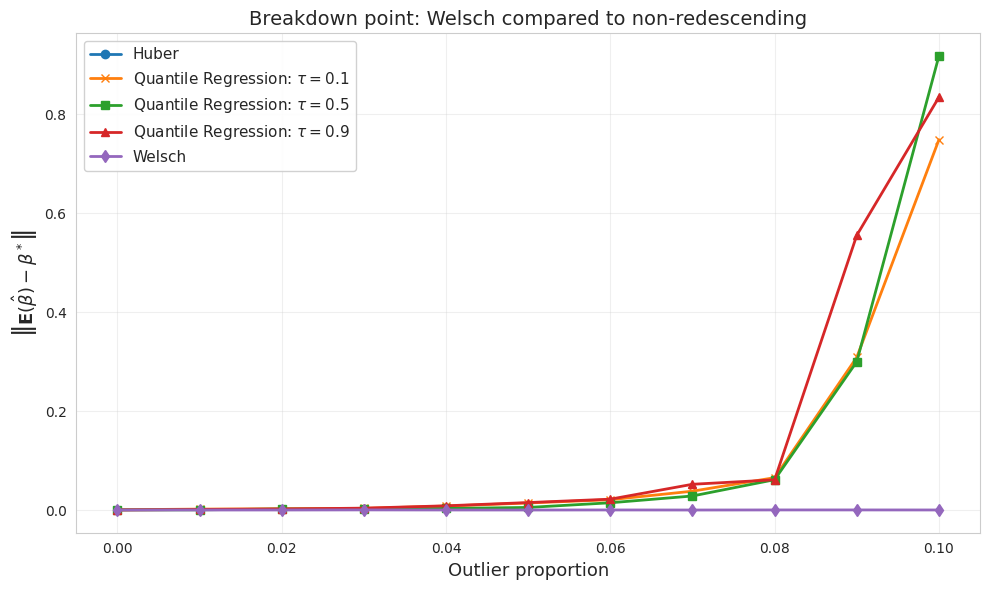

In [212]:
plt.figure(figsize=(10, 6))

plt.plot(break_down_huber_df['delta'], break_down_huber_df['Error'],
         label='Huber', marker='o', linewidth=2)
plt.plot(break_down_quantile_1_df['delta'], break_down_quantile_1_df['Error'],
         label=r'Quantile Regression: $\tau=0.1$', marker='x', linewidth=2)
plt.plot(break_down_quantile_5_df['delta'], break_down_quantile_5_df['Error'],
         label=r'Quantile Regression: $\tau=0.5$', marker='s', linewidth=2)
plt.plot(break_down_quantile_9_df['delta'], break_down_quantile_9_df['Error'],
         label=r'Quantile Regression: $\tau=0.9$', marker='^', linewidth=2)
plt.plot(break_down_Welsch_df['delta'], break_down_Welsch_df['Error'],
         label='Welsch', marker='d', linewidth=2)

plt.xlabel('Outlier proportion', fontsize=13)
plt.ylabel(r'$\left\| \mathbf{E}(\hat{\beta}) - \beta^* \right\|$', fontsize=13)
plt.title('Breakdown point: Welsch compared to non-redescending', fontsize=14)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

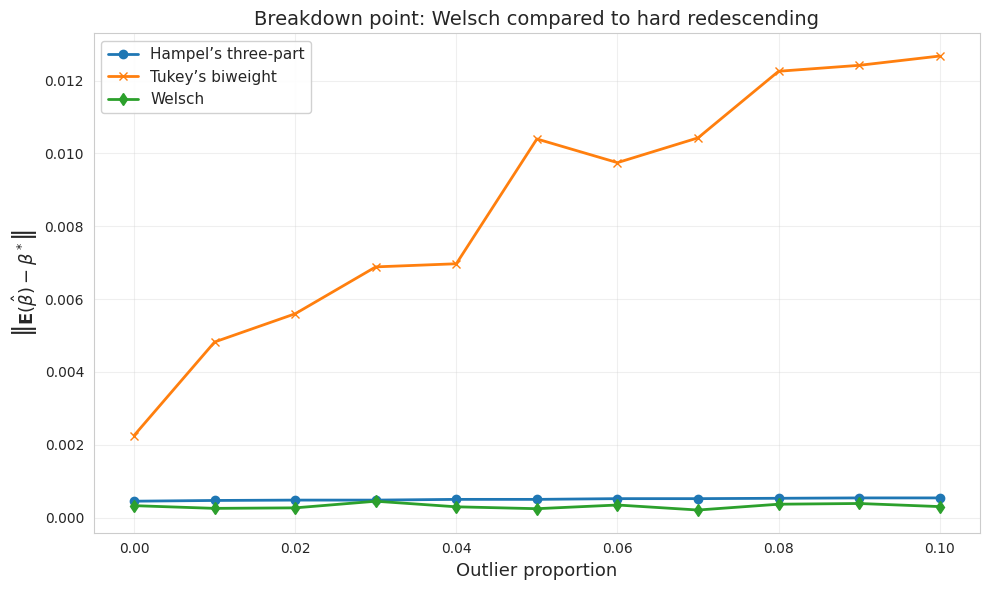

In [213]:
plt.figure(figsize=(10, 6))

plt.plot(break_down_hampel_df['delta'], break_down_hampel_df['Error'],
         label='Hampel’s three-part', marker='o', linewidth=2)
plt.plot(break_down_tukey_df['delta'], break_down_tukey_df['Error'],
         label='Tukey’s biweight', marker='x', linewidth=2)
plt.plot(break_down_Welsch_df['delta'], break_down_Welsch_df['Error'],
         label='Welsch', marker='d', linewidth=2)

plt.xlabel('Outlier proportion', fontsize=13)
plt.ylabel(r'$\left\| \mathbf{E}(\hat{\beta}) - \beta^* \right\|$', fontsize=13)
plt.title('Breakdown point: Welsch compared to hard redescending', fontsize=14)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mean Square Error

### Huber VS Welsch

#### General Setup

In [ ]:
N_SAMPLES = 10_000
P_FEATURES = 10
BETA_SCALE = 1000
OUTLIER_SCALE =1000000
DELTA = 0.01
NUM_REPETITIONS = 1000
MAX_ITER = 100
SEED = 100
NUM_BATCH_MSE_ESTIMATION=1000
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES
per_outliers=0.1


#### Welsch

In [ ]:
MSE_Welsch=[]
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Welsch:"):
    SE_Welsch=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Welsch:"):
            seed=exp*rep
            tau = (tau_base + per_outliers)
            y,X,_ = generate_linear_model(
                N_SAMPLES,
                P_FEATURES,
                beta_star,
                seed=seed,
                outliers=True,
                outlier_const=OUTLIER_SCALE,
                noise_type="pareto",
                outliers_perc=per_outliers,
            )
    
            model = WelschAlgoNonAdaptative(X, y)
            beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
            SE_Welsch.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    MSE_Welsch.append(np.mean(SE_Welsch))

#### Huber

In [ ]:
MSE_Huber= []
 
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Huber:"):
    SE_Huber=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Huber:"):
        seed=exp*rep
        gamma =np.sqrt(P_FEATURES/N_SAMPLES)+per_outliers
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
        model = HuberAlgo(X, y)
        beta_hat, _ = model.optimizer_approach(gamma=gamma, max_iter=1000)
 
        SE_Huber.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    MSE_Huber.append(np.mean(SE_Huber))

#### Distribution of the MSE of Huber and Welsch estimators under corruption

Since the above experiments take long time we provide the results we got in the folder results_break_down_points

##### Downloading Data

In [ ]:
MSE_Huber_Welsch = pd.read_csv("../Results/MSE/histogram_data_Huber_Welsch.csv")
 
welsch = MSE_Huber_Welsch[MSE_Huber_Welsch["Estimator"] == "Welsch"]
huber = MSE_Huber_Welsch[MSE_Huber_Welsch["Estimator"] == "Huber"]

##### Histogram

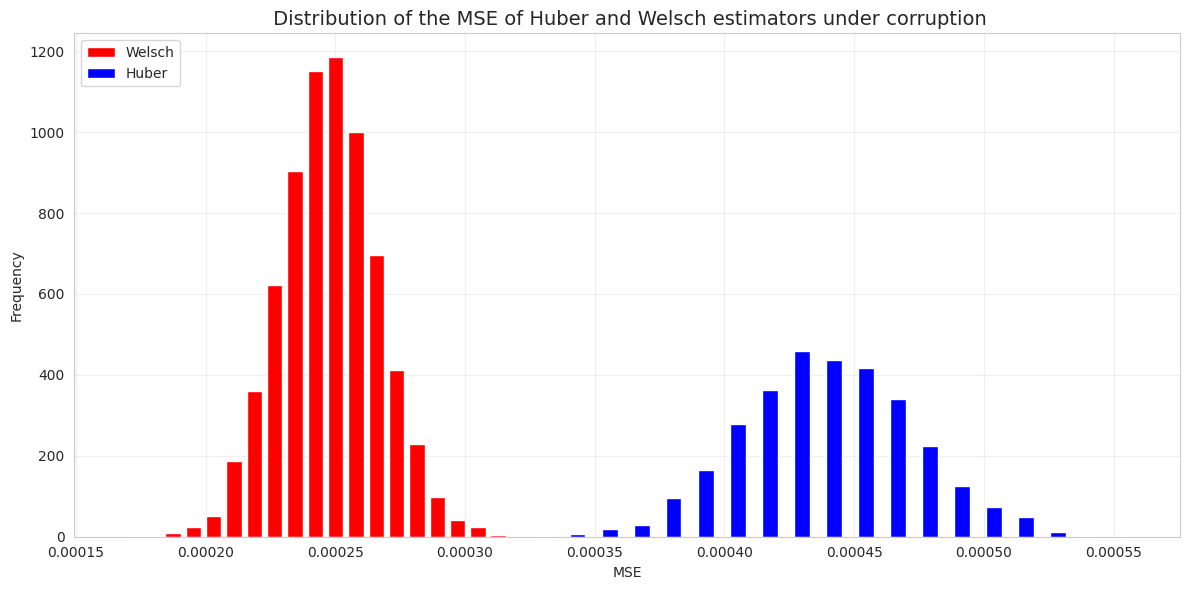

In [215]:
fig, ax = plt.subplots(figsize=(12, 6))
 
bar_width = 0.000006
 
ax.bar(welsch["MSE"], welsch["Frequency"], width=bar_width, color="red", label="Welsch")
ax.bar(huber["MSE"], huber["Frequency"], width=bar_width, color="blue", label="Huber")
 
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.title(' Distribution of the MSE of Huber and Welsch estimators under corruption', fontsize=14)
plt.tight_layout()
plt.show()

### Welsch VS Redecenders

#### General Setup

In [ ]:
N_SAMPLES = 10000
P_FEATURES = 10
BETA_SCALE = 1000
OUTLIER_SCALE =10000000
DELTA = 0.01
NUM_REPETITIONS = 1000
MAX_ITER = 100
SEED = 100
NUM_BATCH_MSE_ESTIMATION=1000
 
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES
per_outliers=0.2

#### Welsch

In [ ]:
MSE_Welsch_Redecenders=[]
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Welsch:"):
    SE_Welsch=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Welsch:"):
        seed=exp*(rep+1)
        tau = tau_base + per_outliers
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=seed
        )
 
        model = WelschAlgoNonAdaptative(X_train, y_train)
        beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
 
        SE_Welsch.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    
    MSE_Welsch_Redecenders.append(np.mean(SE_Welsch))


#### Tukey’s biweight

In [ ]:
MSE_Tukey = []
c_values=np.linspace(3, 6, 4)
 
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Tukey:"):
    SE_Tukey=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Tukey:"):
        seed=exp*rep
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=seed
        )
 
        # Tune Tukey constant on validation set
        best_c = grid_search_cv_tukey(
            X_val, y_val, c_values,
            n_splits=5
        )
 
        # Refit on training set with best parameters
        rlm_model = sm.RLM(y_train, X_train, M=TukeyBiweight(c=best_c))
        beta_hat = rlm_model.fit().params
        SE_Tukey.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    
    MSE_Tukey.append(np.mean(SE_Tukey))

#### Hampel’s three-part

In [ ]:
MSE_Hampel = []
A_VALUES = [1.5, 2.0,4.0]
B_VALUES = [3.0, 4.0, 5.0]
C_VALUES = [6.0, 8.0, 10.0]
 

 
for exp in tqdm(range(NUM_REPETITIONS), desc="MSE Hampel:"):
    SE_Hampel=[]
    for rep in tqdm(range(NUM_BATCH_MSE_ESTIMATION), desc="Squared error Hampel:"):
        seed=exp*rep
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=seed,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=seed
        )
 
        # Tune Hampel constants on validation set
        best_params = grid_search_cv_hampel(
            X_val, y_val, A_VALUES, B_VALUES, C_VALUES,
            n_splits=5, random_state=seed,
        )
 
        # Refit on training set with best parameters
        model = RLM(y_train, X_train, M=Hampel(**best_params))
        beta_hat = model.fit().params
 
        SE_Hampel.append(np.linalg.norm(beta_star - beta_hat) ** 2)
    MSE_Hampel.append(np.mean(SE_Hampel))

#### Distribution of the MSE of redescending estimators under heavy corruption.

##### Downloading Data

In [ ]:
KDE_redecenders = pd.read_csv("../Results/MSE/kde_Welsch_Hampel_Tukey.csv")

##### Histogram

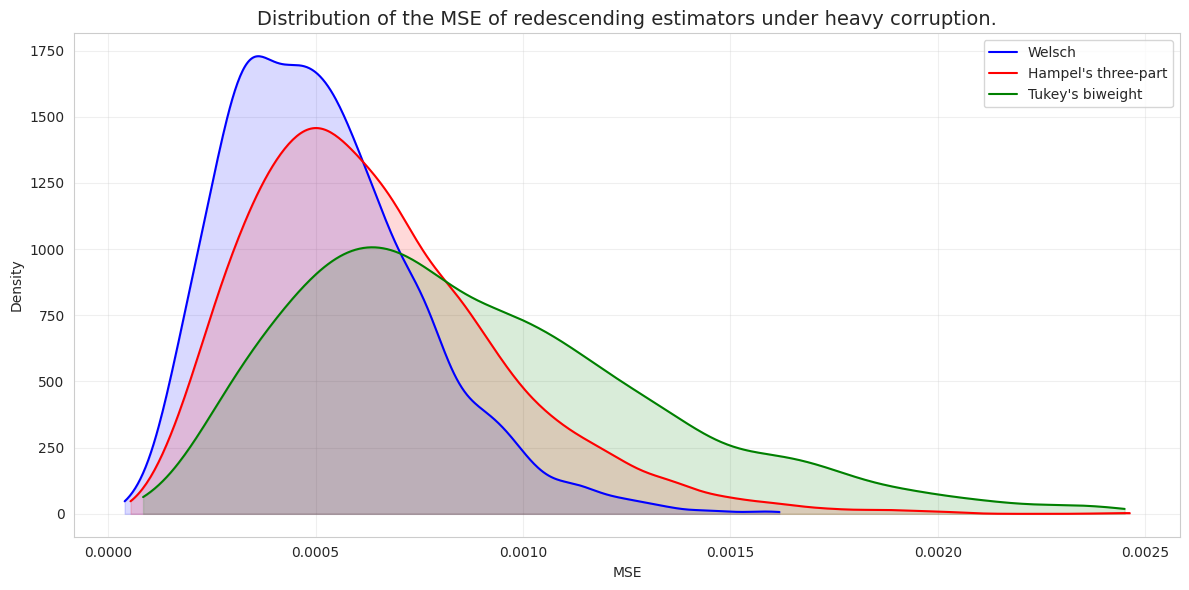

In [217]:
fig, ax = plt.subplots(figsize=(12, 6))
 
colors = {"Welsch": "blue", "Hampel's three-part": "red", "Tukey's biweight": "green"}
 
for series, color in colors.items():
    subset = KDE_redecenders[KDE_redecenders["Estimators"] == series]
    ax.plot(subset["x"], subset["density"], color=color, label=series, linewidth=1.5)
    ax.fill_between(subset["x"], subset["density"], alpha=0.15, color=color)
 
ax.set_xlabel("MSE")
ax.set_ylabel("Density")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.title('Distribution of the MSE of redescending estimators under heavy corruption.', fontsize=14)
plt.tight_layout()
plt.show()

# Real-world data

## Armes Housing

### Downloading the data

In [5]:
Housing=pd.read_csv("../Data/Ames_Housing_Data.csv")

In [6]:
y=Housing['SalePrice'].values
X=Housing.drop('SalePrice', axis=1).values

### Data splitting 20% for fine tuning params 80% for leave out CV

In [7]:
seed = 42
idx = np.arange(len(y))

idx_tune, idx_eval = train_test_split(idx, test_size=0.80, random_state=seed, shuffle=True)

X_tune, y_tune = X[idx_tune], y[idx_tune]
X_eval, y_eval = X[idx_eval], y[idx_eval]

### Tukey

In [10]:
c_values = np.linspace(2, 10, 10)

In [12]:
best_c=grid_search_cv_tukey(X_tune,y_tune,c_values,n_splits=5)
print(best_c)

8.222222222222221


In [8]:
best_c=8.222222222222221

In [9]:
y_oof_pred_turkey, residuals_turkey, metrics_turkey = kfold_cv_tukey(
    X_eval, y_eval, c=best_c, n_splits=5, seed=42
)

### Huber

In [44]:
gamma_values = np.linspace(1, 100000, 100)

In [45]:
Huber = HuberAlgo(X_tune,y_tune)
best_gamma=Huber.grid_search_cv(gamma_values,approach_method='optimizer',n_splits=10)

Grid search: 100%|██████████| 100/100 [04:07<00:00,  2.47s/it]


In [20]:
print(best_gamma)

66.67


In [10]:
best_gamma=66.67

In [11]:
y_oof_pred_Huber, residuals_Huber, metrics_Huber = kfold_cv_huber(
    X_eval, y_eval, best_gamma=best_gamma, n_splits=5, seed=42
)


### Welsch

In [12]:
tau_values = np.linspace(1e-5,10 , 100)

In [ ]:
Welsch = WelschAlgoAdaptative(X_tune,y_tune)
best_tau=Welsch.grid_search_cv(tau_values,approach_method='optimizer',n_splits=10)

Grid search: 100%|██████████| 100/100 [07:19<00:00,  4.39s/it]


In [23]:
print(best_tau)

0.5555555555555559


In [24]:
y_oof_pred_Welsch, residuals_Welsch, metrics_Welsch = kfold_cv_welsch(
    X_eval, y_eval, best_tau=best_tau, n_splits=5, seed=42
)

### Hampel

In [25]:
a_list = np.linspace(1, 20, 30)
b_list = np.linspace(1, 20, 30)
c_list = np.linspace(1, 20, 30)

In [28]:
best_params= grid_search_cv_hampel(
                X_tune, y_tune, a_list, b_list, c_list,
                n_splits=5
            )

In [30]:
print(best_params)

{'a': np.float64(9.517241379310345), 'b': np.float64(15.413793103448276), 'c': np.float64(20.0)}


In [31]:
y_oof_pred_Hampel, residuals_Hampel, metrics_Hampel = kfold_cv_hampel(
    X_eval, y_eval, best_params=best_params, n_splits=5, seed=42
)

### LAD

In [39]:
y_oof_pred_LAD, residuals_LAD, metrics_LAD = kfold_cv_lad(
    X_eval, y_eval, n_splits=5, seed=42
)

### Distribution of the residuals of the Welsch estimator compared to non-redescenders.

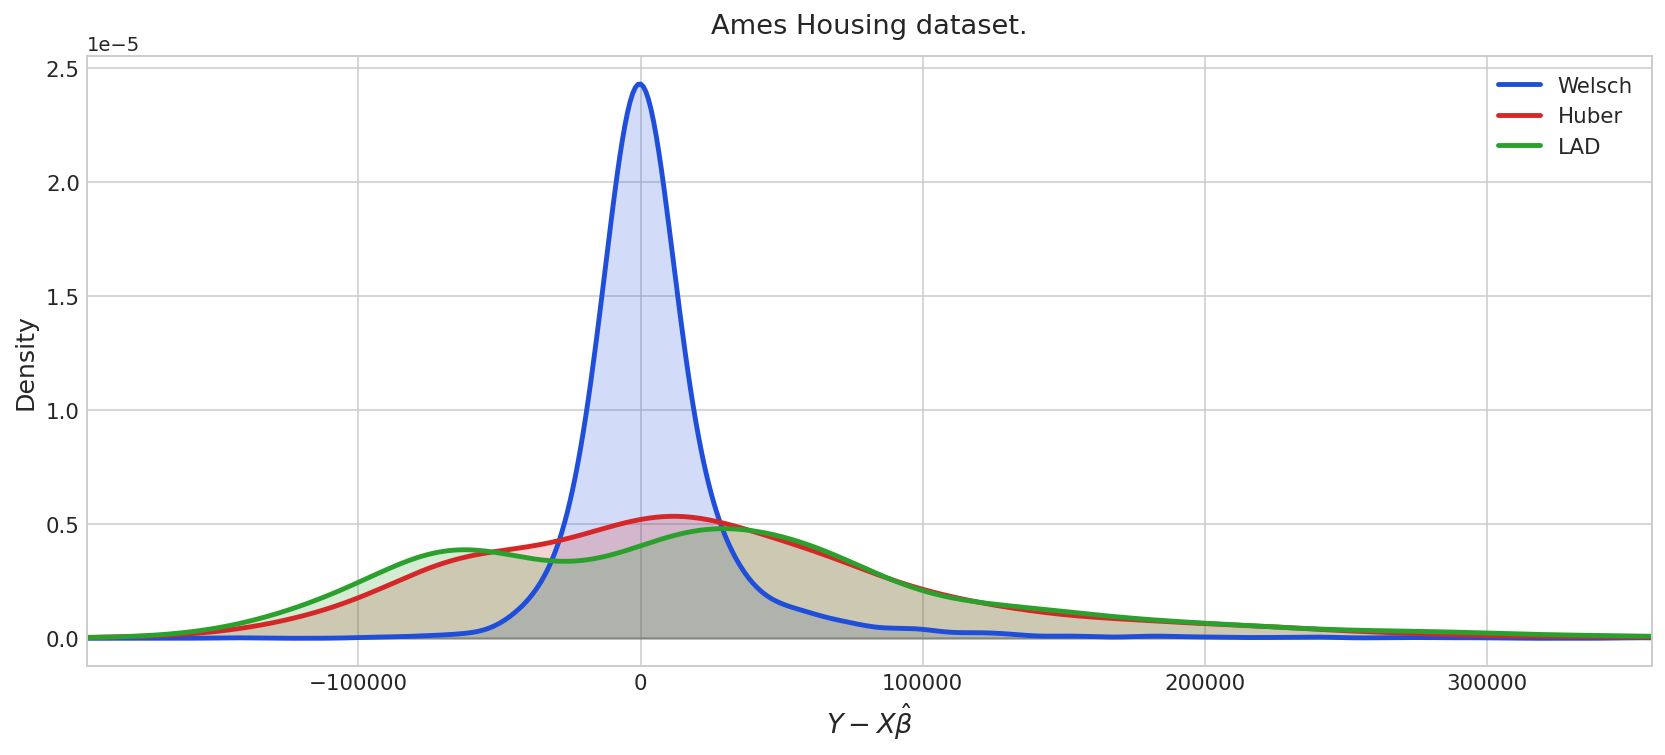

In [40]:
plt.style.use('seaborn-v0_8-whitegrid')  # light grid background

# --- Data ---
residuals = {
    'Welsch':           np.array(residuals_Welsch).flatten().astype(float),
    "Huber": np.array(residuals_Huber).flatten().astype(float),
    "LAD":    np.array(residuals_LAD).flatten().astype(float),
}

colors = {
    'Welsch':              '#1f4eda',
    "Huber": '#d62728',
    "LAD":    '#2ca02c',
}

# --- Robust x-limits ---
all_res = np.concatenate([r[~np.isnan(r)] for r in
                          [np.array(v).flatten().astype(float) for v in residuals.values()]])
lo, hi = np.percentile(all_res, [1, 99])
margin = (hi - lo) * 0.15
x_grid = np.linspace(lo - margin, hi + margin, 600)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=140)

for name, res in residuals.items():
    res = res[~np.isnan(res)]
    kde = gaussian_kde(res, bw_method='scott')
    kde_vals = kde(x_grid)

    ax.fill_between(x_grid, kde_vals, alpha=0.20, color=colors[name])
    ax.plot(x_grid, kde_vals, color=colors[name], lw=2.5, label=name)

# --- Styling ---
ax.set_xlim(x_grid[0], x_grid[-1])
ax.set_xlabel(r'$Y - X\hat{\beta}$', fontsize=14)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Ames Housing dataset.',
             fontsize=14, pad=12)
ax.legend(fontsize=11, loc='upper right')
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.savefig('kde_residuals.png', bbox_inches='tight')
plt.show()

In [44]:
all_metrics = {}
for m in [metrics_LAD, metrics_Welsch, metrics_Huber]:
    for name, values in m.items():
        all_metrics[name.replace(" Metrics", "")] = values

df_metrics = pd.DataFrame(all_metrics).T
df_metrics.index.name = "Estimator"
df_metrics.style \
    .format("{:.6f}") \
    .set_caption("K-Fold Cross-Validation — Robust Estimators") \
    .highlight_min(axis=0, props='background-color: #d4edda; font-weight: bold;') \
    .highlight_max(axis=0, props='background-color: #f8d7da; font-weight: bold;') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '14px',
        'padding': '12px 18px',
        'border': '1px solid #ccc',
        'color': '#1a1a1a',
        'background-color': 'white',
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '18px'),
            ('font-weight', 'bold'),
            ('padding-bottom', '14px'),
            ('color', '#222'),
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-size', '14px'),
            ('font-weight', '600'),
            ('text-align', 'center'),
            ('padding', '12px 18px'),
            ('border', '1px solid #2c3e50'),
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('background-color', '#34495e'),
            ('color', 'white'),
            ('font-size', '14px'),
            ('font-weight', '600'),
            ('text-align', 'left'),
            ('padding', '12px 18px'),
        ]},
        {'selector': 'td', 'props': [
            ('border-bottom', '1px solid #e0e0e0'),
            ('background-color', 'white'),
        ]},
        {'selector': 'tr:hover td', 'props': [
            ('background-color', '#f0f4f8'),
        ]},
        {'selector': '', 'props': [
            ('border-collapse', 'collapse'),
            ('margin', '20px auto'),
        ]},
    ])

,Median of MedAE,Median of MeanAE,Median of IQR
Estimator,,,
LAD,61719.192892,77156.824401,121830.800599
Welsch,9656.324547,17372.717386,19707.558594
Huber,59894.757859,71338.184950,113709.678737


### Distribution of the residuals of the Welsch estimator compared to other redescenders.

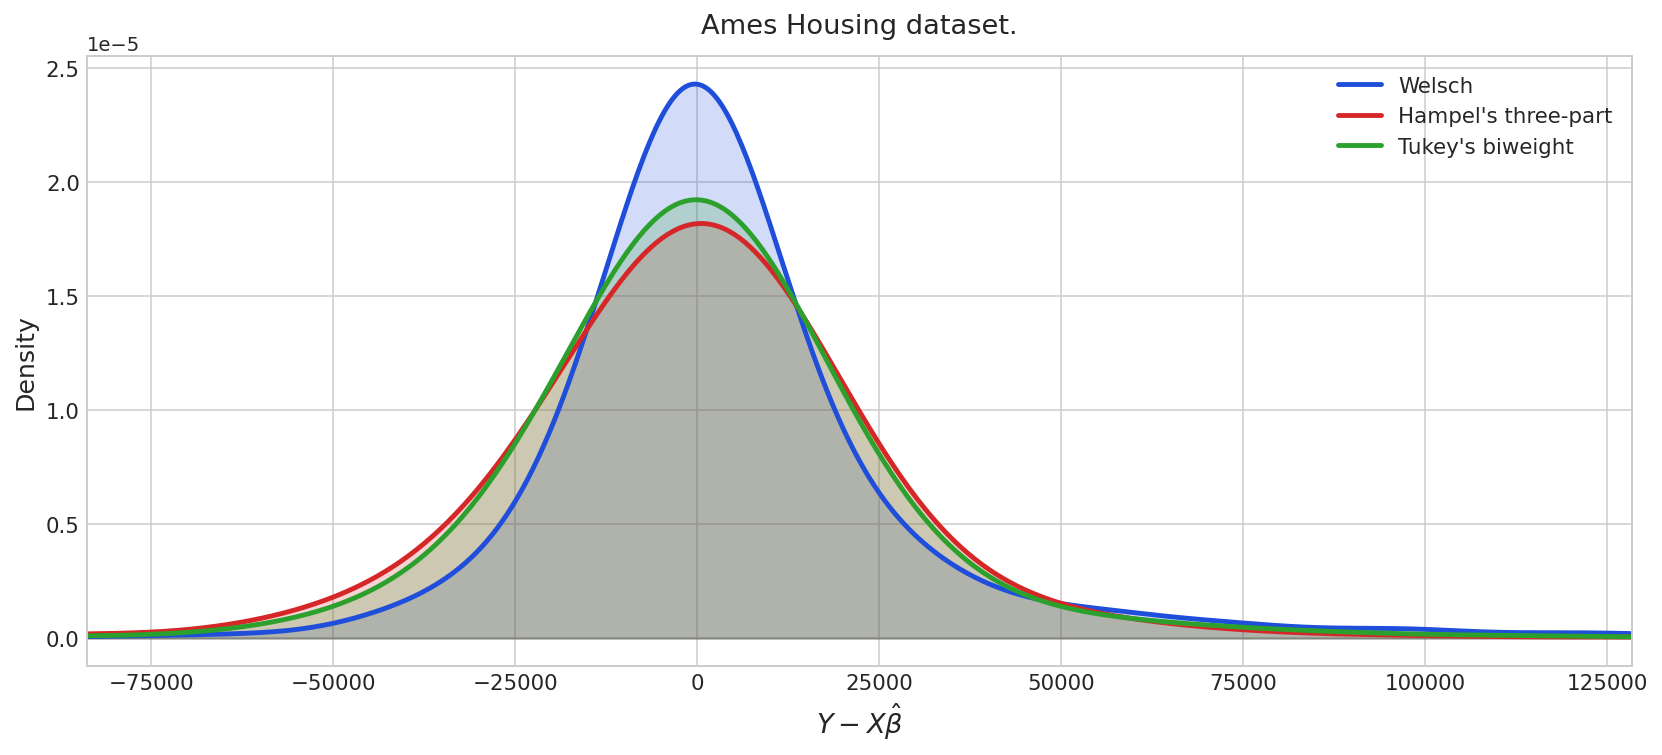

In [38]:
plt.style.use('seaborn-v0_8-whitegrid')  # light grid background

# --- Data ---
residuals = {
    'Welsch':           np.array(residuals_Welsch).flatten().astype(float),
    "Hampel's three-part": np.array(residuals_Hampel).flatten().astype(float),
    "Tukey's biweight":    np.array(residuals_turkey).flatten().astype(float),
}

colors = {
    'Welsch':              '#1f4eda',
    "Hampel's three-part": '#d62728',
    "Tukey's biweight":    '#2ca02c',
}

# --- Robust x-limits ---
all_res = np.concatenate([r[~np.isnan(r)] for r in
                          [np.array(v).flatten().astype(float) for v in residuals.values()]])
lo, hi = np.percentile(all_res, [1, 99])
margin = (hi - lo) * 0.15
x_grid = np.linspace(lo - margin, hi + margin, 600)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=140)

for name, res in residuals.items():
    res = res[~np.isnan(res)]
    kde = gaussian_kde(res, bw_method='scott')
    kde_vals = kde(x_grid)

    ax.fill_between(x_grid, kde_vals, alpha=0.20, color=colors[name])
    ax.plot(x_grid, kde_vals, color=colors[name], lw=2.5, label=name)

# --- Styling ---
ax.set_xlim(x_grid[0], x_grid[-1])
ax.set_xlabel(r'$Y - X\hat{\beta}$', fontsize=14)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Ames Housing dataset.',
             fontsize=14, pad=12)
ax.legend(fontsize=11, loc='upper right')
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.savefig('kde_residuals.png', bbox_inches='tight')
plt.show()

In [45]:
all_metrics = {}
for m in [metrics_turkey, metrics_Welsch, metrics_Hampel]:
    for name, values in m.items():
        all_metrics[name.replace(" Metrics", "")] = values

df_metrics = pd.DataFrame(all_metrics).T
df_metrics.index.name = "Estimator"
df_metrics.style \
    .format("{:.6f}") \
    .set_caption("K-Fold Cross-Validation — Robust Estimators") \
    .highlight_min(axis=0, props='background-color: #d4edda; font-weight: bold;') \
    .highlight_max(axis=0, props='background-color: #f8d7da; font-weight: bold;') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '14px',
        'padding': '12px 18px',
        'border': '1px solid #ccc',
        'color': '#1a1a1a',
        'background-color': 'white',
    }) \
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '18px'),
            ('font-weight', 'bold'),
            ('padding-bottom', '14px'),
            ('color', '#222'),
        ]},
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-size', '14px'),
            ('font-weight', '600'),
            ('text-align', 'center'),
            ('padding', '12px 18px'),
            ('border', '1px solid #2c3e50'),
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('background-color', '#34495e'),
            ('color', 'white'),
            ('font-size', '14px'),
            ('font-weight', '600'),
            ('text-align', 'left'),
            ('padding', '12px 18px'),
        ]},
        {'selector': 'td', 'props': [
            ('border-bottom', '1px solid #e0e0e0'),
            ('background-color', 'white'),
        ]},
        {'selector': 'tr:hover td', 'props': [
            ('background-color', '#f0f4f8'),
        ]},
        {'selector': '', 'props': [
            ('border-collapse', 'collapse'),
            ('margin', '20px auto'),
        ]},
    ])

,Median of MedAE,Median of MeanAE,Median of IQR
Estimator,,,
Tukey Biweight,11037.565376,18737.788801,22075.550098
Welsch,9656.324547,17372.717386,19707.558594
Hampel,12081.223645,19535.147125,24038.337729


## Abalone

### Downloading the data

In [49]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

In [50]:
X.drop('Sex',axis=1,inplace=True)
#X["Sex"] = X["Sex"].map({"F": 0, "M": 1, "I": 2})
X = X.to_numpy(dtype=float)
y = y.iloc[:, 0].to_numpy(dtype=float)

/tmp/ipykernel_228286/3175103093.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('Sex',axis=1,inplace=True)


### Data splitting 20% for fine tuning params 80% for leave out CV

In [51]:
seed = 42  # Fixed seed same data for all estimators
idx = np.arange(len(y))

idx_tune, idx_eval = train_test_split(idx, test_size=0.80, random_state=seed, shuffle=True)

X_tune, y_tune = X[idx_tune], y[idx_tune]
X_eval, y_eval = X[idx_eval], y[idx_eval]

### Hampel

In [52]:
a_list = np.linspace(1, 20, 30)
b_list = np.linspace(1, 20, 30)
c_list = np.linspace(1, 20, 30)

In [ ]:
best_params= grid_search_cv_hampel(
                X_tune, y_tune, a_list, b_list, c_list,
                n_splits=5
            )